In [1]:
import torch
import numpy as np

In [2]:
x_np = np.random.random((4,4))
print(x_np)
x_pt = torch.tensor(x_np)
print(x_pt)

[[0.53512512 0.01442225 0.63954835 0.61889629]
 [0.57517708 0.47765691 0.15234472 0.12474753]
 [0.45319248 0.68052964 0.92497513 0.24247   ]
 [0.85634361 0.89334504 0.47313558 0.21532365]]
tensor([[0.5351, 0.0144, 0.6395, 0.6189],
        [0.5752, 0.4777, 0.1523, 0.1247],
        [0.4532, 0.6805, 0.9250, 0.2425],
        [0.8563, 0.8933, 0.4731, 0.2153]], dtype=torch.float64)


In [4]:
print(x_np.dtype,x_pt.dtype)
x_np = np.asarray(x_np,dtype=np.float32)
x_pt = torch.tensor(x_np,dtype=torch.float32)
print(x_np.dtype,x_pt.dtype)

float64 torch.float64
float32 torch.float32


In [6]:
b_np = (x_np>.5)
print(b_np,b_np.dtype)
b_pt = (x_pt > .5)
print(b_pt,b_pt.dtype)

[[ True False  True  True]
 [ True False False False]
 [False  True  True False]
 [ True  True False False]] bool
tensor([[ True, False,  True,  True],
        [ True, False, False, False],
        [False,  True,  True, False],
        [ True,  True, False, False]]) torch.bool


In [7]:
np.sum(x_np)
torch.sum(x_pt)

tensor(7.8772)

In [9]:
np.transpose(x_np)
torch.transpose(x_pt,0,1)

tensor([[0.5351, 0.5752, 0.4532, 0.8563],
        [0.0144, 0.4777, 0.6805, 0.8933],
        [0.6395, 0.1523, 0.9250, 0.4731],
        [0.6189, 0.1247, 0.2425, 0.2153]])

In [10]:
import timeit
x = torch.rand(2**11,2**11)
time_cpu = timeit.timeit("x@x", globals=globals(),number=100)
print(time_cpu)

9.299454200000127


In [11]:
print("is Cuda available: ",torch.cuda.is_available())
device = torch.device("cuda")

is Cuda available:  True


In [13]:
x = x.to(device)
time_gpu = timeit.timeit("x@x",globals=globals(),number=100)
print(time_gpu)

0.15326950000007855


In [ ]:
x = torch.rand(128,128).to(device)
y = torch.rand(128,128) # without .to(device) we get error
x*y

tensor([[2.6807e-02, 1.5942e-01, 1.6171e-01,  ..., 1.0982e-01, 1.1251e-01,
         1.0972e-01],
        [3.6573e-01, 2.0053e-03, 1.7053e-01,  ..., 6.8883e-01, 3.7419e-02,
         5.5497e-01],
        [3.2319e-01, 9.0223e-02, 1.8597e-04,  ..., 5.7641e-01, 6.1367e-01,
         1.4891e-01],
        ...,
        [1.8464e-01, 3.6235e-02, 1.0711e-01,  ..., 8.2440e-02, 2.7148e-01,
         3.3157e-01],
        [2.0296e-01, 1.8403e-02, 9.3854e-02,  ..., 4.1644e-01, 1.2416e-01,
         1.7417e-01],
        [1.7644e-02, 1.8269e-02, 8.0970e-03,  ..., 4.1995e-01, 4.5372e-01,
         3.5027e-03]], device='cuda:0')

In [17]:
def MoveTo(obj,device):
    if isinstance(obj,list):
        return [MoveTo(x,device) for x in obj]
    elif isinstance(obj,tuple):
        return tuple(MoveTo(list(obj),device))
    elif isinstance (obj, set):
        return set(MoveTo(list(obj),device))
    elif isinstance(obj, dict):
        to_ret = dict()
        for key,value in obj.items():
            to_ret[MoveTo(key,device)]=MoveTo(value,device)
        return to_ret
    elif hasattr(obj,"to"):
        return obj.to(device)
    else:
        return obj
    


In [19]:
some_tensores = [torch.tensor(1),torch.tensor(2)]
print(some_tensores)
print(MoveTo(some_tensores,device))


[tensor(1), tensor(2)]
[tensor(1, device='cuda:0'), tensor(2, device='cuda:0')]


In [20]:
import seaborn as sns

<Axes: >

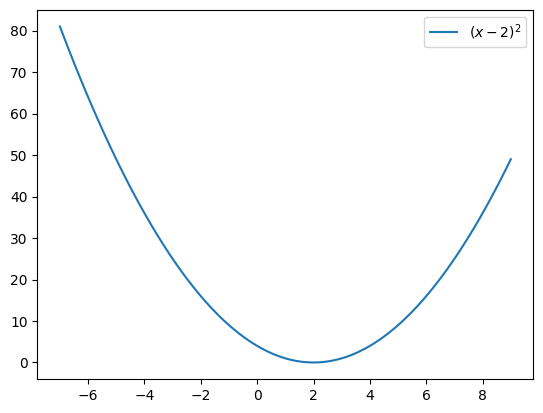

In [21]:
def f(x):
    return torch.pow((x-2.0),2)
x_axes_values = np.linspace(-7,9,100)
y_axes_values = f(torch.tensor(x_axes_values)).numpy()
sns.lineplot(x=x_axes_values,y=y_axes_values, label="$(x-2)^2$")

<Axes: >

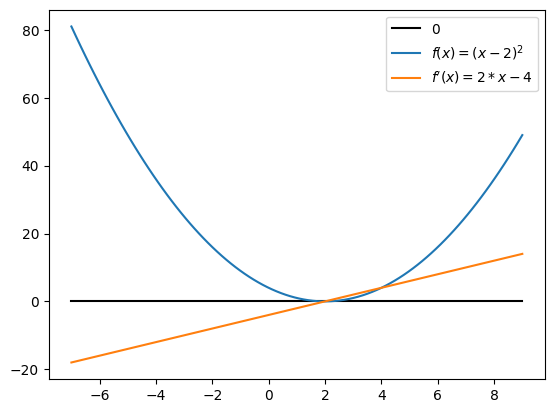

In [22]:
def fP(x):
    return 2*x-4

y_axes_values_p = fP(torch.tensor(x_axes_values)).numpy()
sns.lineplot(x=x_axes_values,y=[0.0]*len(x_axes_values),label="0",color='black')
sns.lineplot(x=x_axes_values,y=y_axes_values,label="$f(x)=(x-2)^2$")
sns.lineplot(x=x_axes_values,y=y_axes_values_p,label="$f'(x)=2*x-4$")


In [ ]:
x = torch.tensor([-3.58],requires_grad=True)
print(x.grad)

None


In [ ]:
value =f(x)
print(value)

tensor([110.8809], grad_fn=<PowBackward0>)


In [26]:
value.backward()
print(x.grad)

tensor([21.0600])


In [27]:
x = torch.tensor([-3.5],requires_grad=True)
x_cur=x.clone()
x_prev = x_cur*100
epsilon = 1e-5
eta = 0.1

while torch.linalg.norm(x_cur-x_prev)>epsilon:
    x_prev=x_cur.clone()
    value = f(x)
    value.backward()
    x.data -=eta*x.grad

    x.grad.zero_()
    x_cur = x.data

print(x_cur)

tensor([2.0000])


In [28]:
x_param = torch.nn.Parameter(torch.tensor([-3.5]),requires_grad=True)
optimizer = torch.optim.SGD([x_param],lr =eta)
for epoch in range(60):
    optimizer.zero_grad()
    loss_incurred = f(x_param)
    loss_incurred.backward()
    optimizer.step()
print(x_param.data)


tensor([2.0000])


In [ ]:
from torch.utils.data import Dataset
from sklearn.datasets import fetch_openml
X ,y = fetch_openml('mnist_784',version=1,return_X_y=True)
print(X.shape)

In [ ]:
class SimpleDataset(Dataset):
    def __init__(self,X,y):
        super(SimpleDataset,self).__init__()
        self.X=X
        self.y = y
    def __getitem__(self,index):
        inputs = torch.tensor(self.X[index,:],dtype=torch.float32)
        targets = torch.tensor(int(self.y[index]),dtype=torch.int64)
        return inputs,targets
    def __len__(self):
        return self.X.shape[0]
    
dataset = SimpleDataset(X,y)


In [ ]:
print("Length: ",len(dataset))
example , label = dataset[0]
print("Features: ",example.shape)
print("label of index 0: ", label)


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(example.reshape((28,28)))

In [ ]:
train_size = int(len(dataset)*0.8)
test_size = len(dataset) - train_size
train_dataset,test_dataset = torch.utils.data.random_split(dataset,(train_size,test_size))

print(f"{len(train_dataset)} example for training and {test_dataset} examples for test")


## Exercises

In [2]:
import torch


In [3]:
torch_tensor3d = torch.tensor(torch.rand(4,2,3))
def tensor3dAve(tensor3d):
    s = 0
    c = 0
    for i in range(len(tensor3d)):
        for j in range(len(tensor3d[i])):
            for k in range(len(tensor3d[i][j])):
                s += tensor3d[i][j][k]
                c +=1
    return s/c
    
print(torch_tensor3d)
print(tensor3dAve(torch_tensor3d))

tensor([[[0.6206, 0.2173, 0.0150],
         [0.2569, 0.4191, 0.0889]],

        [[0.7919, 0.8390, 0.2325],
         [0.6292, 0.9358, 0.7720]],

        [[0.3622, 0.5662, 0.7459],
         [0.4456, 0.2292, 0.5903]],

        [[0.7672, 0.2008, 0.7978],
         [0.1162, 0.8131, 0.0207]]])
tensor(0.4781)


C:\Users\Mohammad\AppData\Local\Temp\ipykernel_11116\2482380934.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch_tensor3d = torch.tensor(torch.rand(4,2,3))


In [4]:
import time
import matplotlib.pyplot as plt


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sizes = []
cpu_times =[]
gpu_times = []

for i in range(1,14):
    n = 2**i
    sizes.append(n)

    X_cpu = torch.rand((n,n))
    start = time.time()
    y = X_cpu @ X_cpu
    cpu_time = time.time() - start
    cpu_times.append(cpu_time)

    if torch.cuda.is_available():
        X_gpu = X_cpu.to(device)
        torch.cuda.synchronize()
        start = time.time()
        y = X_gpu @ X_gpu
        torch.cuda.synchronize()
        gpu_time = time.time() - start
    else:
        gpu_time = float("nan")

    gpu_times.append(gpu_time)

speedup = [c/g if g != 0 and not torch.isnan(torch.tensor(g)) else float('nan')
           for c, g in zip(cpu_times, gpu_times)]






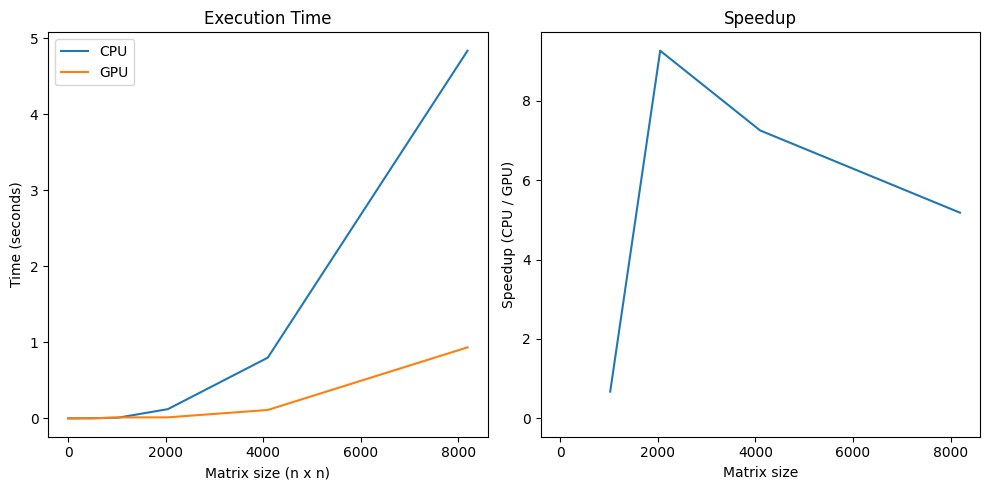

In [8]:
# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(sizes, cpu_times, label="CPU")
plt.plot(sizes, gpu_times, label="GPU")
plt.xlabel("Matrix size (n x n)")
plt.ylabel("Time (seconds)")
plt.legend()
plt.title("Execution Time")

plt.subplot(1,2,2)
plt.plot(sizes, speedup)
plt.xlabel("Matrix size")
plt.ylabel("Speedup (CPU / GPU)")
plt.title("Speedup")

plt.tight_layout()
plt.show()